In [1]:
import matplotlib.pyplot as plt
from lj_model.config import initial_condition_lines, make_default_params, model_switch_lines
from lj_model.jet_model import compute_nozzle_diagnostics, solve_jet
from lj_model.nucleation import compute_survival, run_parametric_study
from lj_model.plotting import create_figure
from lj_model.validation import run_smoke_tests


# OPERATING CONDITIONS


In [2]:
params = make_default_params()
print('\n'.join(initial_condition_lines(params)))


INITIAL CONDITIONS
Nozzle diameter     : 20.0 um
Flow rate           : 0.60 uL/min
Jet velocity        : 31.8 m/s
Chamber pressure    : 1.00e-03 Pa (1.00e-05 mbar)
Vapor back pressure : 0.00e+00 Pa
Nozzle temp         : 293.15 K
Gas temp            : 293.15 K


# MODEL SWITCHES


In [3]:
print('\n'.join(model_switch_lines(params)))


use_radial_profile            : True
use_surface_waves             : True
use_temp_dependent_properties : True
use_back_pressure             : True
use_diffusion_limit           : True (applies only for Kn < 0.1)
freeze_model                  : empirical_backstop (empirical freeze onset at 263.15 K; CNT remains a liquid-branch diagnostic)
velocity_assumption           : constant axial speed from incompressible surface recession continuity
alpha_evap                    : 0.9


# NOTEBOOK MODULE LAYOUT


In [4]:
print('properties.py   : thermophysical correlations and vapor pressure')
print('evaporation.py  : HK flux, continuum diffusion reference, Knudsen gating')
print('jet_model.py    : breakup estimate, ODE, event builders, solver wrapper')
print('nucleation.py   : CNT rate, survival curve, parametric study')
print('plotting.py     : figures, summary panel, breakup annotations')
print('validation.py   : smoke tests used by validate_lj_model.py')


properties.py   : thermophysical correlations and vapor pressure
evaporation.py  : HK flux, continuum diffusion reference, Knudsen gating
jet_model.py    : breakup estimate, ODE, event builders, solver wrapper
nucleation.py   : CNT rate, survival curve, parametric study
plotting.py     : figures, summary panel, breakup annotations
validation.py   : smoke tests used by validate_lj_model.py


# DIAGNOSTICS


In [5]:
nozzle = compute_nozzle_diagnostics(params)
print('\n'.join(nozzle.report_lines(params)))


DIAGNOSTICS
Net evap flux at nozzle: 2.28e+00 kg/m2/s
  HK limit             : 2.28e+00 kg/m2/s
  Diffusion limit      : gated off in free-molecular regime (raw continuum value 4.55e+06)
Cooling rate (1-D)     : 8.57e+03 K/m
Re=636  We=278.60  Oh=0.0263
Rayleigh breakup       : 1.09 mm  (34.2 us)
Fourier no. at breakup : 0.049  (>1=isothermal, <0.1=strong gradient)
Delta relaxation len   : 2.79 mm
Quasi-steady dT_surf   : 23.9 K below mean
Knudsen number         : 6.65e+05 (free-molecular)
sigma(T_nozzle)        : 0.0727 N/m
mu(T_nozzle)           : 1.002e-03 Pa s
cp(T_nozzle)           : 4181.6 J/kg/K
k(T_nozzle)            : 0.597 W/m/K
Adiabatic freeze frac. : 0.128 of the jet if freezing starts at 263.15 K
Velocity model         : constant axial speed; this is continuity-consistent for incompressible surface recession.
Freeze interpretation  : empirical_backstop at 263.15 K; CNT is reported only on the liquid branch.


# SOLVE


In [6]:
solution = solve_jet(params)
print('\n'.join(solution.report_lines(params)))



SOLVING JET ODE
Integration stopped at breakup: z = 1.09 mm

At z = 1.09 mm:
  T_mean    = 286.34 K
  T_surface = 283.57 K
  T_center  = 289.11 K
  Delta     = 5.54 K
  r         = 9.943 μm

Total evaporation rate: 113.359 ng/s


# NUCLEATION SURVIVAL CURVE


In [7]:
nucleation = compute_survival(params, solution)
print('\n'.join(nucleation.report_lines()))



NUCLEATION STATISTICS  (CNT, homogeneous)
z_10 (10% frozen) : not reached
z_50 (median)     : not reached
z_90 (90% frozen) : not reached
P_survival at end : 1.0000
Interpretation     : Ended by Rayleigh breakup before empirical freeze onset or CNT median nucleation.


# PARAMETRIC STUDY: freeze position vs T_nozzle


In [8]:
parametric = run_parametric_study(params)
print('\n'.join(parametric.report_lines()))


Parametric study done. CNT z50 range: not reached
Parametric end-surface range at termination: 270.72 - 283.49 K


# SMOKE-TEST VALIDATION


In [9]:
for line in run_smoke_tests():
    print(f'SMOKE: {line}')


SMOKE: Property correlations return plausible values at 293 K and 273 K.
SMOKE: Hertz-Knudsen and continuum diffusion reference fluxes are positive.
SMOKE: Default ODE integration terminates at or before Rayleigh breakup.
SMOKE: CNT survival curve is monotonically non-increasing.


# PLOTTING


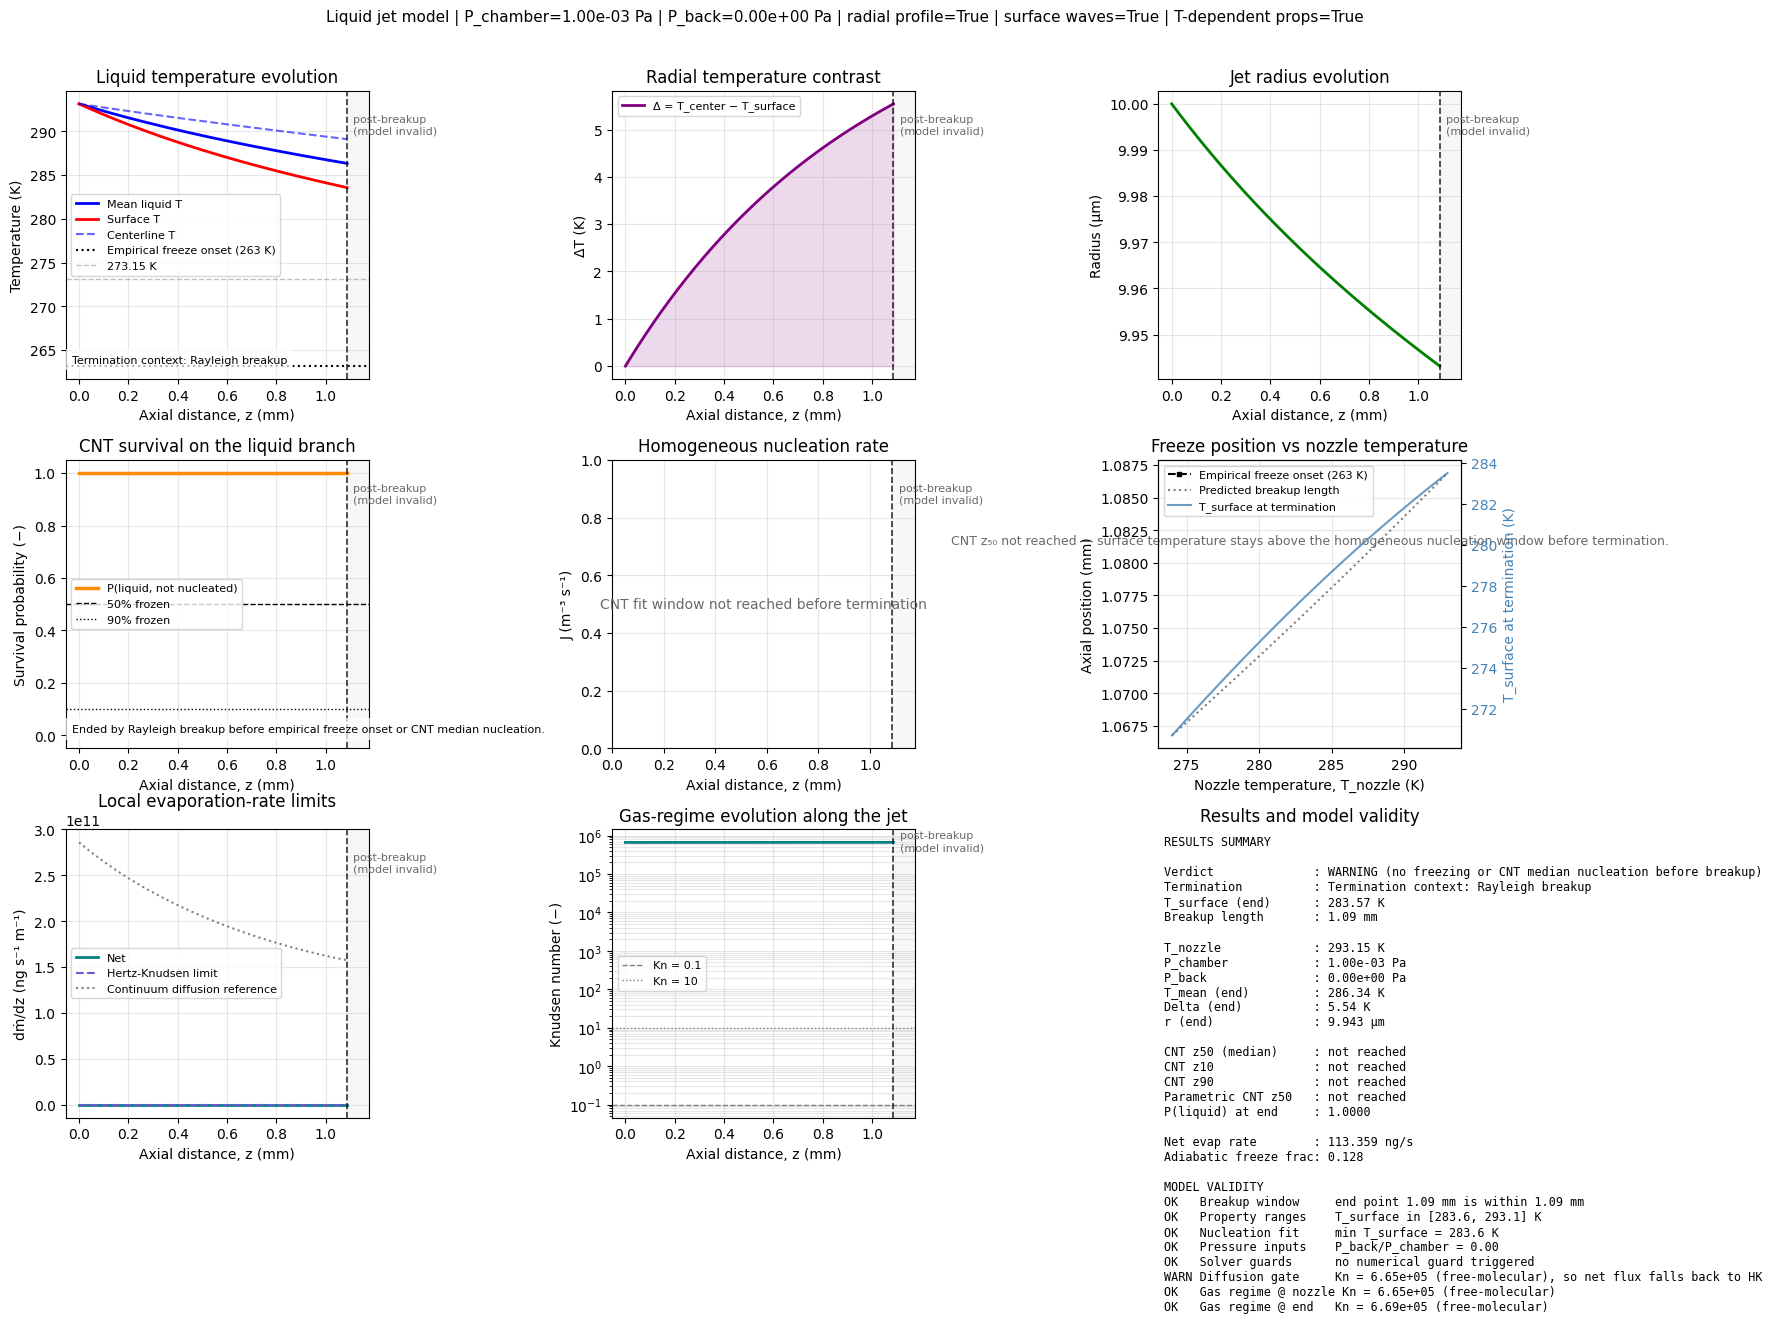

Saved jet_analysis.png
RESULTS SUMMARY

Verdict              : WARNING (no freezing or CNT median nucleation before breakup)
Termination          : Termination context: Rayleigh breakup
T_surface (end)      : 283.57 K
Breakup length       : 1.09 mm

T_nozzle             : 293.15 K
P_chamber            : 1.00e-03 Pa
P_back               : 0.00e+00 Pa
T_mean (end)         : 286.34 K
Delta (end)          : 5.54 K
r (end)              : 9.943 μm

CNT z50 (median)     : not reached
CNT z10              : not reached
CNT z90              : not reached
Parametric CNT z50   : not reached
P(liquid) at end     : 1.0000

Net evap rate        : 113.359 ng/s
Adiabatic freeze frac: 0.128

MODEL VALIDITY
OK   Breakup window     end point 1.09 mm is within 1.09 mm
OK   Property ranges    T_surface in [283.6, 293.1] K
OK   Nucleation fit     min T_surface = 283.6 K
OK   Pressure inputs    P_back/P_chamber = 0.00
OK   Solver guards      no numerical guard triggered
WARN Diffusion gate     Kn = 6.65e+05 

In [10]:
fig, axes, summary = create_figure(params, solution, nucleation, parametric, output_path='jet_analysis.png')
plt.show()
print('Saved jet_analysis.png')
print(summary)
